In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('C:/Users/navee/Desktop/house_price_prediction/data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [2]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [4]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [5]:
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values after cleaning: 0


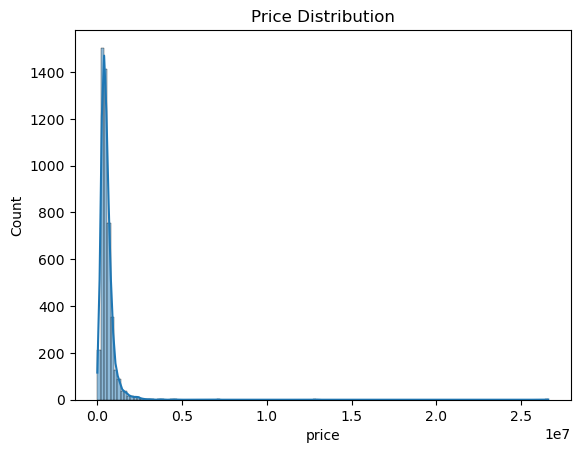

In [6]:
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

In [7]:
df['price'] = np.log1p(df['price'])
print("Log transformation completed.")
df['price'].head()

Log transformation completed.


0    12.653962
1    14.684291
2    12.742569
3    12.948012
4    13.217675
Name: price, dtype: float64

In [8]:
df = pd.get_dummies(df, drop_first=True)
print("New shape after encoding:", df.shape)

New shape after encoding: (4600, 4725)


In [9]:
X = df.drop('price', axis=1)
y = df['price']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4600, 4724)
Target shape: (4600,)


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling completed.")

Scaling completed.


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (3680, 4724)
Testing data shape: (920, 4724)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
print("Creating models...")
lr = LinearRegression()
rf = RandomForestRegressor(
    n_estimators=50,   
    random_state=42,
    n_jobs=-1
)
gb = GradientBoostingRegressor(random_state=42)
print("Training Linear Regression...")
lr.fit(X_train, y_train)
print("Linear Regression completed.")
print("Training Random Forest...")
rf.fit(X_train, y_train)
print("Random Forest completed.")
print("Training Gradient Boosting...")
gb.fit(X_train, y_train)
print("Gradient Boosting completed.")
print("All models trained successfully!")

Creating models...
Training Linear Regression...
Linear Regression completed.
Training Random Forest...
Random Forest completed.
Training Gradient Boosting...
Gradient Boosting completed.
All models trained successfully!


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

def evaluate_model(model, name):   
    preds = model.predict(X_test)    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae
    }
results = pd.DataFrame([
    evaluate_model(lr, "Linear Regression"),
    evaluate_model(rf, "Random Forest"),
    evaluate_model(gb, "Gradient Boosting")
])
results = results.sort_values("RMSE")
results

,Model,RMSE,MAE
0,Linear Regression,1.370693,0.418375
2,Gradient Boosting,1.390384,0.474242
1,Random Forest,1.401948,0.335217


In [14]:
best_model = gb
print("Best model selected:", type(best_model).__name__)

Best model selected: GradientBoostingRegressor


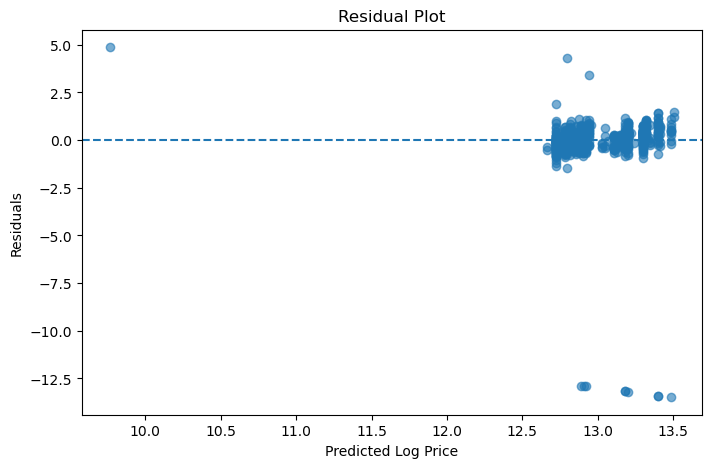

In [15]:
import matplotlib.pyplot as plt
preds = best_model.predict(X_test)
residuals = y_test - predsplt.figure(figsize=(8, 5))
plt.scatter(preds, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [16]:
import joblib
joblib.dump(best_model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [17]:
model = joblib.load("house_price_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")
sample = X.iloc[[0]]
sample_scaled = scaler_loaded.transform(sample)
pred_log = model.predict(sample_scaled)
pred_price = np.expm1(pred_log)
print("Predicted House Price:", pred_price[0])

Predicted House Price: 334410.743940675
